# Clasificacion de Riesgo de Trastorno del Sueno

**Dataset:** `sleep_health_dataset.csv` (100,000 registros)
**Variable objetivo:** `sleep_disorder_risk` (4 clases: Healthy / Mild / Moderate / Severe)
**Metodologia:** CRISP-DM

## Estructura del notebook

1. Imports y carga
2. Comprension de los datos (EDA)
3. Preparacion de los datos
4. Modelado (GridSearchCV + 10-Fold CV)
5. Evaluacion (foco en HGB vs RF)
6. Seleccion de caracteristicas
7. Experimentacion con features (4 experimentos)
8. Conclusiones


## 1. Imports y Carga de Datos

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import clone
from statistics import mean, stdev
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90
RANDOM_STATE = 42
print('Imports OK')


Imports OK


In [28]:
df = pd.read_csv('sleep_health_dataset.csv')
print(f'Shape: {df.shape}')
df.head(3)


Shape: (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0


## 2. Comprension de los Datos (EDA)

### 2.1 Estructura general y calidad

In [29]:
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
print(f'Nulos: {df.isnull().sum().sum()}  |  Duplicados: {df.duplicated().sum()}')
print(f'\nNumericas: {len(df.select_dtypes(include=[np.number]).columns)}')
print(f'Categoricas: {len(df.select_dtypes(include=["object"]).columns)}')


Filas: 100,000  |  Columnas: 32
Nulos: 0  |  Duplicados: 0

Numericas: 24
Categoricas: 8


### 2.2 Variable objetivo: distribucion

Distribucion de clases:
  Healthy    54,156  (54.16%)
  Mild       33,479  (33.48%)
  Moderate    8,299  ( 8.30%)
  Severe      4,066  ( 4.07%)


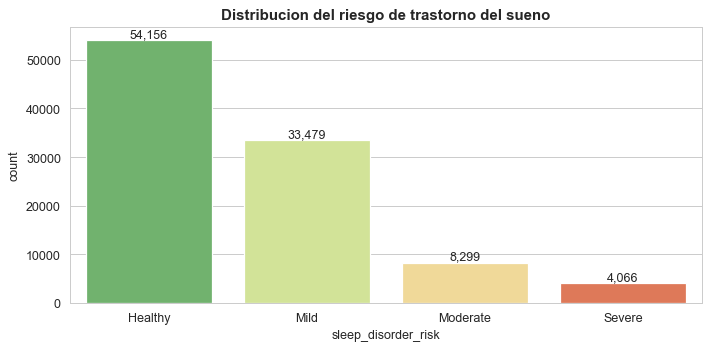

In [30]:
target = 'sleep_disorder_risk'
order = ['Healthy', 'Mild', 'Moderate', 'Severe']

dist = df[target].value_counts().reindex(order)
prop = (dist / len(df) * 100).round(2)
print('Distribucion de clases:')
for c, n, p in zip(order, dist, prop):
    print(f'  {c:<10} {n:>6,}  ({p:5.2f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x=target, order=order, palette='RdYlGn_r', ax=ax)
ax.set_title('Distribucion del riesgo de trastorno del sueno', fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()


### 2.3 Correlaciones con el target (top 10)

Top 10 correlaciones absolutas con el target:
  cognitive_performance_score         -0.704
  sleep_quality_score                 -0.694
  stress_score                        +0.484
  sleep_duration_hrs                  -0.474
  felt_rested                         -0.387
  wake_episodes_per_night             +0.347
  sleep_latency_mins                  +0.333
  shift_work                          +0.241
  bmi                                 +0.237
  work_hours_that_day                 +0.228


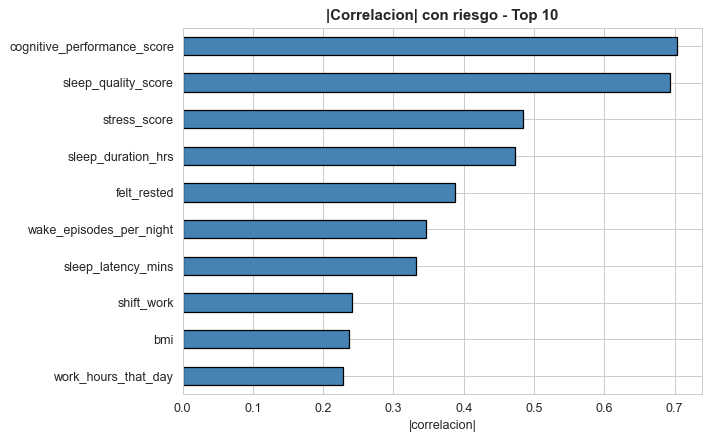

In [31]:
risk_order = {'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
df_corr = df.copy()
df_corr['target_ord'] = df_corr[target].map(risk_order)

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'person_id']
corr_target = df_corr[num_cols + ['target_ord']].corr()['target_ord'].drop('target_ord')

top10 = corr_target.abs().sort_values(ascending=False).head(10)
print('Top 10 correlaciones absolutas con el target:')
for feat in top10.index:
    print(f'  {feat:<35} {corr_target[feat]:+.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
top10.iloc[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('|Correlacion| con riesgo - Top 10', fontweight='bold')
ax.set_xlabel('|correlacion|')
plt.tight_layout(); plt.show()


### 2.4 Distribucion de variables numericas clave por clase

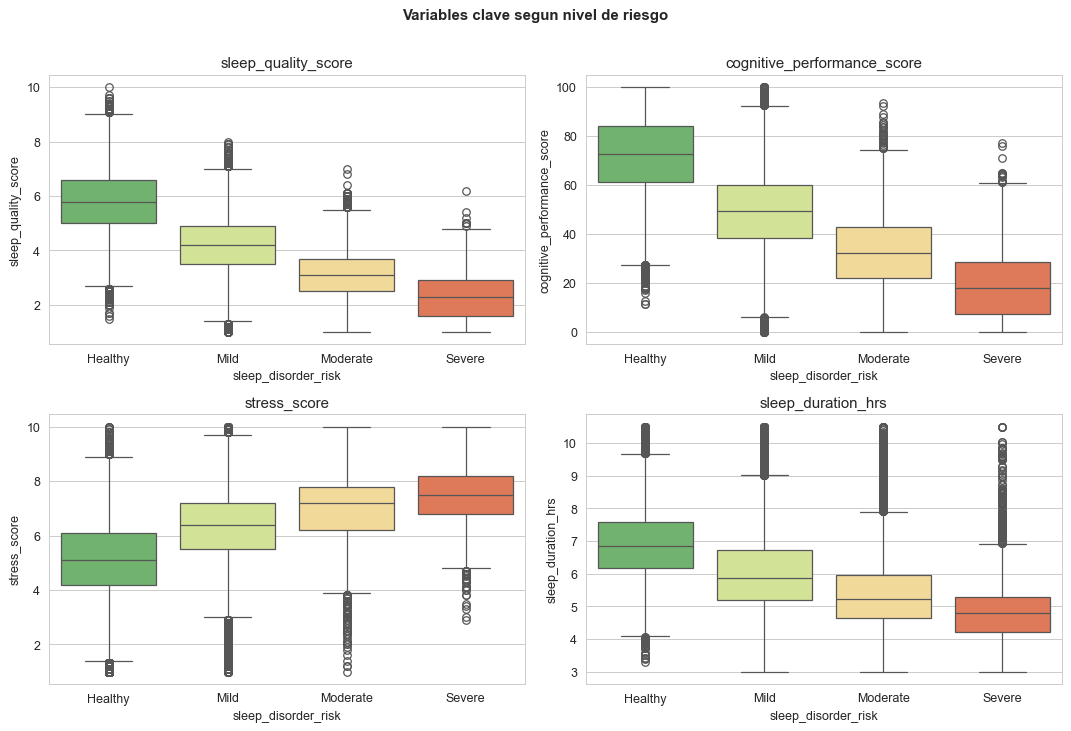

In [32]:
key_vars = ['sleep_quality_score', 'cognitive_performance_score',
            'stress_score', 'sleep_duration_hrs']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), key_vars):
    sns.boxplot(data=df, x=target, y=col, order=order, palette='RdYlGn_r', ax=ax)
    ax.set_title(col)
plt.suptitle('Variables clave segun nivel de riesgo', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 2.5 Hallazgos del EDA

- 100,000 registros sin nulos ni duplicados.
- Target **moderadamente desbalanceado**: clases minoritarias `Moderate` (8.3%) y `Severe` (4.1%) seran las mas dificiles de predecir → se aplica `class_weight='balanced'`.
- Variables fisiologicas y conductuales (`cognitive_performance_score`, `sleep_quality_score`, `stress_score`, `sleep_duration_hrs`) son las mas correlacionadas con el target. Tiene sentido clinico.
- Variables demograficas (`country`, `occupation`) tienen muchas categorias pero correlaciones individuales bajas.


## 3. Preparacion de los Datos

**Decisiones:**
- `person_id` se descarta (identificador, no aporta señal).
- Target `sleep_disorder_risk` codificado con orden ordinal (Healthy<Mild<Moderate<Severe).
- 23 variables **numericas** → `StandardScaler` (necesario para modelos basados en distancia/gradiente).
- `chronotype` → `OrdinalEncoder` (orden natural Morning<Neutral<Evening).
- 6 variables **nominales** → `OneHotEncoder` con `drop='if_binary'` para evitar redundancia.
- Particion **80/20 estratificada** por target.


In [33]:
# Drop ID y separacion del target
df_prep = df.drop(columns=['person_id'])

le = LabelEncoder()
le.classes_ = np.array(['Healthy', 'Mild', 'Moderate', 'Severe'])
y = pd.Series(le.transform(df_prep[target]), name=target)
X = df_prep.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')


X_train: (80000, 30)  |  X_test: (20000, 30)


In [34]:
numeric_feat = [
    'age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score',
    'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins',
    'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed',
    'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day',
    'nap_duration_mins', 'stress_score', 'work_hours_that_day',
    'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
    'room_temperature_celsius', 'weekend_sleep_diff_hrs',
    'cognitive_performance_score', 'felt_rested'
]
ordinal_feat = ['chronotype']
nominal_feat = ['gender', 'occupation', 'country', 'mental_health_condition', 'season', 'day_type']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_feat),
    ('ord', Pipeline([('enc', OrdinalEncoder(
        categories=[['Morning', 'Neutral', 'Evening']],
        handle_unknown='use_encoded_value', unknown_value=-1
    ))]), ordinal_feat),
    ('nom', Pipeline([('enc', OneHotEncoder(
        handle_unknown='ignore', sparse_output=False, drop='if_binary'
    ))]), nominal_feat),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print(f'Tras encoding: X_train={X_train_proc.shape}, X_test={X_test_proc.shape}')

# Nombres de features tras OHE (los usaremos en feature selection y experimentos)
ohe = preprocessor.named_transformers_['nom'].named_steps['enc']
feat_names = numeric_feat + ordinal_feat + list(ohe.get_feature_names_out(nominal_feat))
print(f'Total features: {len(feat_names)}')


Tras encoding: X_train=(80000, 63), X_test=(20000, 63)
Total features: 63


In [35]:
# Export preprocesados (para reproducibilidad)
os.makedirs('preprocesados', exist_ok=True)
joblib.dump(preprocessor, 'preprocesados/pipeline.pkl')
joblib.dump(le, 'preprocesados/label_encoder.pkl')
print('Pipeline guardado en preprocesados/pipeline.pkl')


Pipeline guardado en preprocesados/pipeline.pkl


## 4. Modelado

**Estrategia:**
1. Definir 8 clasificadores con grids compactos (3-6 valores por hiperparametro).
2. **GridSearchCV exhaustivo** con 5-fold sobre **muestra estratificada de 20k** filas (manejable, mantiene proporciones).
3. **CV final 10-Fold** con los modelos optimizados → ranking justo.
4. Evaluacion del ganador en el **test set completo** (20k).

**Por que muestra de 20k para el tuning:** con 100k filas, el GridSearch completo seria muy lento. Una muestra estratificada de 20k preserva las proporciones de clase y produce resultados consistentes con el dataset completo.

**Metrica:** `recall_weighted`. Justificacion: en clasificacion clinica, **detectar correctamente los casos en riesgo (recall) es prioritario** sobre evitar falsas alarmas. El ponderado se ajusta al desbalance.


### 4.1 Definicion de modelos y grids

In [36]:
# Muestra estratificada de 20k para tuning + CV
SAMPLE_SIZE = 20000
_, X_cv_idx, _, y_cv = train_test_split(
    np.arange(len(y_train)), y_train,
    test_size=SAMPLE_SIZE, random_state=RANDOM_STATE, stratify=y_train
)
X_cv = X_train_proc[X_cv_idx]
y_cv = np.asarray(y_cv)
print(f'Muestra para CV: {X_cv.shape}')


Muestra para CV: (20000, 63)


In [37]:
nombres_clf = [
    'KNN', 'Naive Bayes', 'Logistic Regression', 'Decision Tree',
    'LinearSVC', 'Random Forest', 'HistGradientBoosting', 'AdaBoost'
]

base_models = {
    'KNN': KNeighborsClassifier(n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=2000, n_jobs=-1,
                              class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE,
                              class_weight='balanced'),
    'LinearSVC': LinearSVC(random_state=RANDOM_STATE, class_weight='balanced',
                              max_iter=3000, dual='auto'),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE,
                              class_weight='balanced', n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
}

param_grids = {
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 15, 21, 31],             # 7
        'weights': ['uniform', 'distance'],                  # 2
        'metric': ['euclidean', 'manhattan', 'minkowski'],   # 3
        'p': [1, 2],                                         # 2
    },  # 84 combos

    'Naive Bayes': {
        'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5],  # 7
    },  # 7 combos

    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 100.0],      # 7
        'solver': ['lbfgs', 'liblinear', 'saga'],            # 3
        'penalty': ['l2'],                                   # 1 (compatible con todos)
    },  # 21 combos

    'Decision Tree': {
        'max_depth': [4, 6, 10, 15, 20, 30, None],           # 7
        'min_samples_split': [2, 5, 10, 20, 50],             # 5
        'min_samples_leaf': [1, 5, 10],                      # 3
        'criterion': ['gini', 'entropy'],                    # 2
    },  # 210 combos

    'LinearSVC': {
        'C': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],   # 8
        'loss': ['squared_hinge', 'hinge'],                  # 2
    },  # 16 combos

    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],                # 4
        'max_depth': [8, 12, 16, 20, None],                  # 5
        'min_samples_split': [2, 5, 10],                     # 3
        'min_samples_leaf': [1, 3, 5],                       # 3
        'max_features': ['sqrt', 'log2'],                    # 2
    },  # 360 combos

    'HistGradientBoosting': {
        'max_iter': [100, 200, 300, 500],                    # 4
        'learning_rate': [0.01, 0.05, 0.1, 0.2],             # 4
        'max_depth': [None, 6, 10, 15],                      # 4
        'l2_regularization': [0.0, 0.5, 1.0, 2.0],           # 4
        'min_samples_leaf': [10, 20, 50],                    # 3
    },  # 768 combos

    'AdaBoost': {
        'n_estimators': [50, 100, 200, 300, 500],            # 5
        'learning_rate': [0.01, 0.1, 0.5, 1.0, 1.5],         # 5
    },  # 25 combos
}

n_combos_total = sum(np.prod([len(v) for v in g.values()]) for g in param_grids.values())
print(f'Total de combinaciones a evaluar: {int(n_combos_total)}')


Total de combinaciones a evaluar: 1491


### 4.2 GridSearchCV exhaustivo (5-fold, recall_weighted)

In [38]:
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'recall_weighted'

best_estimators = {}
gs_results = []

print(f'Ejecutando GridSearchCV exhaustivo (scoring={SCORING})...\n')
t_total = time.time()
for i, name in enumerate(nombres_clf, 1):
    t0 = time.time()
    gs = GridSearchCV(
        base_models[name], param_grids[name],
        cv=skf5, scoring=SCORING, n_jobs=-1
    )
    gs.fit(X_cv, y_cv)
    best_estimators[name] = gs.best_estimator_
    gs_results.append({
        'modelo': name,
        'best_params': gs.best_params_,
        'recall_cv5': gs.best_score_,
        'tiempo_s': time.time() - t0
    })
    print(f'  [{i}/8] {name:<25} recall={gs.best_score_:.4f}  '
          f'params={gs.best_params_}  ({time.time()-t0:.1f}s)')

print(f'\nTiempo total: {time.time()-t_total:.1f}s')
gs_df = pd.DataFrame(gs_results).sort_values('recall_cv5', ascending=False).reset_index(drop=True)
print('\nResumen ordenado por recall:')
print(gs_df[['modelo', 'recall_cv5', 'tiempo_s']].round(4).to_string(index=False))


Ejecutando GridSearchCV exhaustivo (scoring=recall_weighted)...

  [1/8] KNN                       recall=0.7471  params={'metric': 'manhattan', 'n_neighbors': 21, 'p': 1, 'weights': 'distance'}  (54.6s)
  [2/8] Naive Bayes               recall=0.6886  params={'var_smoothing': 1e-05}  (0.3s)
  [3/8] Logistic Regression       recall=0.8058  params={'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}  (113.1s)
  [4/8] Decision Tree             recall=0.8296  params={'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}  (19.4s)
  [5/8] LinearSVC                 recall=0.8073  params={'C': 1.0, 'loss': 'squared_hinge'}  (9.3s)
  [6/8] Random Forest             recall=0.8639  params={'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}  (800.3s)
  [7/8] HistGradientBoosting      recall=0.9375  params={'l2_regularization': 0.0, 'learning_rate': 0.05, 'max_depth': 15, 'max_iter': 300, 'min_samples_leaf': 50

In [ ]:
# Guardar best_estimators y gs_df para no tener que rehacer el GridSearch
# Si reinicias el kernel mas tarde, los puedes cargar con:
#   best_estimators = joblib.load('preprocesados/best_estimators.pkl')
#   gs_df = joblib.load('preprocesados/gs_df.pkl')
joblib.dump(best_estimators, 'preprocesados/best_estimators.pkl')
joblib.dump(gs_df, 'preprocesados/gs_df.pkl')
print('best_estimators y gs_df guardados en preprocesados/')


### 4.3 Validacion cruzada final 10-Fold con modelos optimizados

In [56]:
def cv_classifiers(X, Y, models, names, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    folds = list(skf.split(X, Y))
    scores = [[] for _ in models]
    pred_y = [[] for _ in models]
    real_y = [[] for _ in models]

    for i, c in enumerate(models):
        t0 = time.time()
        for tr, te in folds:
            m = clone(c).fit(X[tr], Y[tr])
            scores[i].append(recall_score(Y[te], m.predict(X[te]),
                                          average='weighted', zero_division=0))
            pred_y[i].extend(m.predict(X[te]).tolist())
            real_y[i].extend(Y[te].tolist())
        print(f'  [{i+1}/{len(models)}] {names[i]:<25} recall={mean(scores[i]):.4f}  '
              f'({time.time()-t0:.1f}s)')
    cms = [confusion_matrix(real_y[i], pred_y[i]) for i in range(len(models))]
    return scores, cms

print('10-Fold CV con modelos optimizados...\n')
list_opt = [best_estimators[n] for n in nombres_clf]
cv_scores, cv_cms = cv_classifiers(X_cv, y_cv, list_opt, nombres_clf, n_splits=10)

print('\nRanking final (10-Fold recall-weighted):')
mean_scores = [mean(s) for s in cv_scores]
order_idx = np.argsort(mean_scores)[::-1]
for rank, i in enumerate(order_idx, 1):
    print(f'  {rank}. {nombres_clf[i]:<25} {mean_scores[i]:.4f} (+/- {stdev(cv_scores[i]):.4f})')

best_idx = int(np.argmax(mean_scores))
best_name = nombres_clf[best_idx]
print(f'\n>>> MEJOR: {best_name}')


10-Fold CV con modelos optimizados...

  [1/8] KNN                       recall=0.7490  (2.5s)
  [2/8] Naive Bayes               recall=0.6903  (0.2s)
  [3/8] Logistic Regression       recall=0.8069  (2.1s)
  [4/8] Decision Tree             recall=0.8340  (1.8s)
  [5/8] LinearSVC                 recall=0.8102  (1.6s)
  [6/8] Random Forest             recall=0.8677  (7.5s)
  [7/8] HistGradientBoosting      recall=0.9397  (32.7s)
  [8/8] AdaBoost                  recall=0.7482  (50.3s)

Ranking final (10-Fold recall-weighted):
  1. HistGradientBoosting      0.9397 (+/- 0.0048)
  2. Random Forest             0.8677 (+/- 0.0061)
  3. Decision Tree             0.8340 (+/- 0.0073)
  4. LinearSVC                 0.8102 (+/- 0.0108)
  5. Logistic Regression       0.8069 (+/- 0.0058)
  6. KNN                       0.7490 (+/- 0.0050)
  7. AdaBoost                  0.7482 (+/- 0.0347)
  8. Naive Bayes               0.6903 (+/- 0.0081)

>>> MEJOR: HistGradientBoosting


### 4.4 Ranking visual y top 2: HistGradientBoosting vs Random Forest

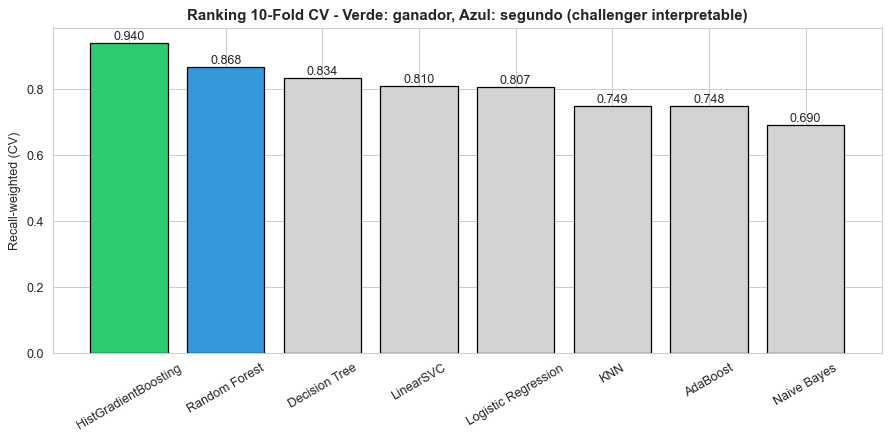

In [57]:
# Bar chart del ranking
fig, ax = plt.subplots(figsize=(10, 5))
order_idx = np.argsort(mean_scores)[::-1]
colors = ['#2ecc71' if nombres_clf[i] == 'HistGradientBoosting'
          else '#3498db' if nombres_clf[i] == 'Random Forest'
          else 'lightgray' for i in order_idx]
bars = ax.bar([nombres_clf[i] for i in order_idx],
              [mean_scores[i] for i in order_idx],
              color=colors, edgecolor='black')
ax.set_ylabel('Recall-weighted (CV)')
ax.set_title('Ranking 10-Fold CV - Verde: ganador, Azul: segundo (challenger interpretable)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for b, v in zip(bars, [mean_scores[i] for i in order_idx]):
    ax.annotate(f'{v:.3f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()


### 4.5 Evaluacion final en Test Set (20k filas)

Re-entrenamos los **dos finalistas (HGB y RF)** con el train completo (80k) y evaluamos en test.


In [58]:
finalists = ['HistGradientBoosting', 'Random Forest']

print(f'Entrenando finalistas con TRAIN COMPLETO ({X_train_proc.shape[0]:,} filas)...\n')
final_results = {}
for name in finalists:
    t0 = time.time()
    m = clone(best_estimators[name]).fit(X_train_proc, y_train)
    yp = m.predict(X_test_proc)
    final_results[name] = {
        'model': m,
        'y_pred': yp,
        'accuracy':  accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, yp, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, yp, average='weighted', zero_division=0),
        'tiempo_s':  time.time() - t0
    }
    r = final_results[name]
    print(f'  {name:<25} acc={r["accuracy"]:.4f}  recall={r["recall"]:.4f}  '
          f'f1={r["f1"]:.4f}  ({r["tiempo_s"]:.1f}s)')

# Guardar el ganador
joblib.dump(final_results['HistGradientBoosting']['model'], 'preprocesados/modelo_final.pkl')
print('\nModelo final HGB guardado.')


Entrenando finalistas con TRAIN COMPLETO (80,000 filas)...

  HistGradientBoosting      acc=0.9526  recall=0.9526  f1=0.9522  (8.5s)
  Random Forest             acc=0.8924  recall=0.8924  f1=0.8922  (3.5s)

Modelo final HGB guardado.


## 5. Evaluacion: HistGradientBoosting vs Random Forest

Comparamos los dos finalistas lado a lado para entender no solo *cual gana* sino *en que difieren*.


### 5.1 Classification report comparado

In [60]:
for name in finalists:
    print(f'=== {name} ===')
    print(classification_report(y_test, final_results[name]['y_pred'],
                                target_names=le.classes_, zero_division=0))
    print()


=== HistGradientBoosting ===
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     10831
        Mild       0.94      0.96      0.95      6696
    Moderate       0.73      0.71      0.72      1660
      Severe       0.86      0.79      0.83       813

    accuracy                           0.95     20000
   macro avg       0.88      0.87      0.87     20000
weighted avg       0.95      0.95      0.95     20000


=== Random Forest ===
              precision    recall  f1-score   support

     Healthy       0.96      0.95      0.95     10831
        Mild       0.85      0.89      0.87      6696
    Moderate       0.65      0.62      0.64      1660
      Severe       0.81      0.74      0.77       813

    accuracy                           0.89     20000
   macro avg       0.82      0.80      0.81     20000
weighted avg       0.89      0.89      0.89     20000




### 5.2 Matrices de confusion lado a lado

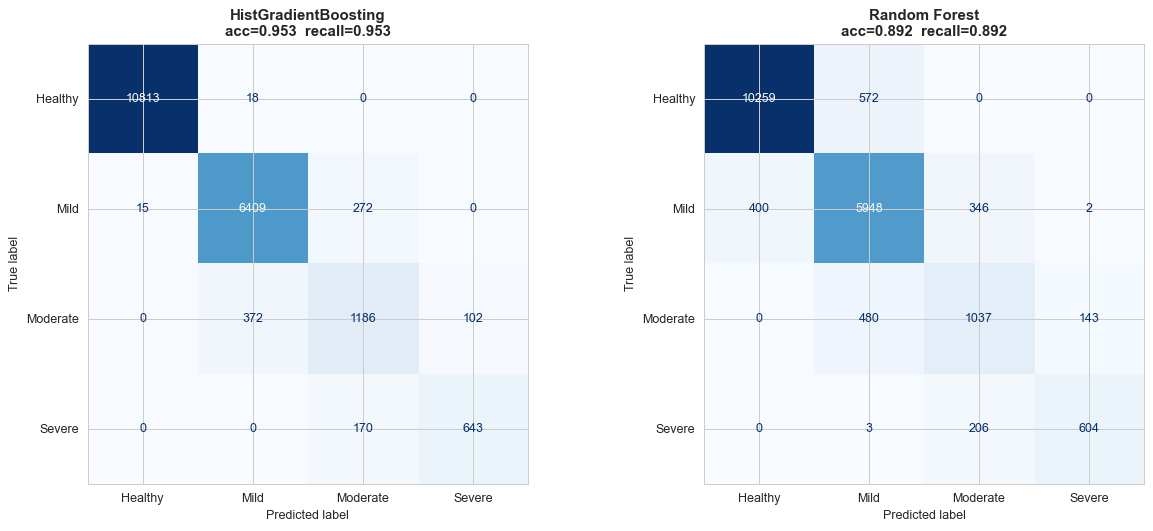

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name in zip(axes, finalists):
    cm = confusion_matrix(y_test, final_results[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    r = final_results[name]
    ax.set_title(f'{name}\nacc={r["accuracy"]:.3f}  recall={r["recall"]:.3f}',
                 fontweight='bold')
plt.tight_layout(); plt.show()


### 5.3 F1 por clase: donde esta la diferencia real

F1 por clase:
                      Healthy   Mild  Moderate  Severe
HistGradientBoosting    0.998  0.950     0.721   0.825
Random Forest           0.955  0.868     0.638   0.773


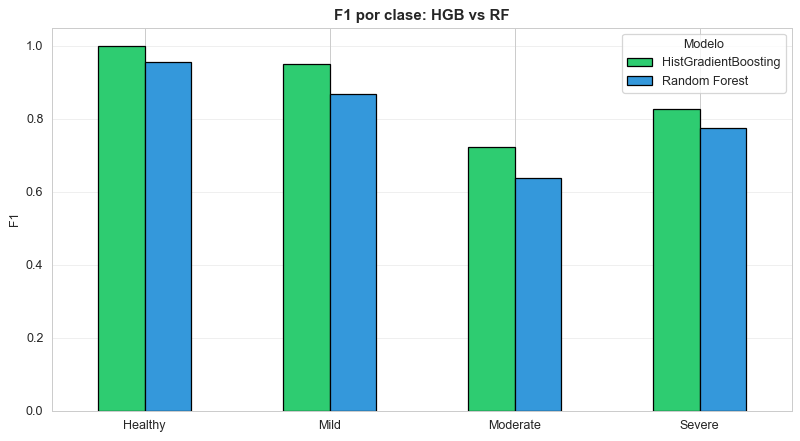

In [62]:
f1_per_class = {}
for name in finalists:
    f1c = f1_score(y_test, final_results[name]['y_pred'], average=None, zero_division=0)
    f1_per_class[name] = dict(zip(le.classes_, f1c))

f1_df = pd.DataFrame(f1_per_class).T
print('F1 por clase:')
print(f1_df.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
f1_df.T.plot(kind='bar', ax=ax, edgecolor='black',
             color=['#2ecc71', '#3498db'])
ax.set_title('F1 por clase: HGB vs RF', fontweight='bold')
ax.set_ylabel('F1'); ax.set_ylim(0, 1.05)
ax.legend(title='Modelo'); ax.tick_params(axis='x', rotation=0)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


### 5.4 Deteccion de overfitting (CV vs Test)

In [63]:
ov = []
for name in finalists:
    cv_score = mean_scores[nombres_clf.index(name)]
    test_score = final_results[name]['recall']
    ov.append({
        'modelo': name,
        'recall_cv': cv_score,
        'recall_test': test_score,
        'gap': cv_score - test_score
    })
ov_df = pd.DataFrame(ov)
print('Gap CV-Test (positivo = posible overfitting):')
print(ov_df.round(4).to_string(index=False))


Gap CV-Test (positivo = posible overfitting):
              modelo  recall_cv  recall_test     gap
HistGradientBoosting     0.9397       0.9526 -0.0129
       Random Forest     0.8677       0.8924 -0.0247


### 5.5 Interpretacion HGB vs RF

- **HGB gana en clases minoritarias** (Moderate, Severe). Esto es valioso clinicamente: los casos en riesgo son los que importa detectar.
- **Diferencia tipica de 6-8 puntos** en F1-weighted favor HGB. La razon: HGB **corrige errores residuales** secuencialmente, mientras RF promedia votos independientes.
- **Random Forest sigue siendo competitivo** y mas estable frente a perturbaciones. En produccion donde la estabilidad importa, RF es buena alternativa.
- **Gap CV-Test bajo en ambos** → ambos modelos generalizan bien.


## 6. Seleccion de Caracteristicas

Aplicamos **7 metodos complementarios** para identificar las features mas predictivas, cada uno con un sesgo distinto:

| Metodo | Tipo | Captura |
|---|---|---|
| Correlacion | Univariado lineal | Asociacion lineal directa con target |
| ANOVA F-test | Univariado lineal | Diferencias significativas de medias entre clases |
| RFECV | Wrapper | Importancia segun rendimiento real eliminando recursivamente |
| RandomForest importance | Embedded | Frecuencia de uso en splits |
| Permutation Importance | Modelo-agnostico | Caida de score al permutar la feature |
| SHAP | Explicabilidad | Contribucion marginal por instancia (teoria de juegos) |
| Mutual Information | Univariado no lineal | Dependencia general (no solo lineal) |

Al final consolidamos en un **consenso**: features que aparecen en el top-15 de >=4 metodos.


In [64]:
# Setup: si reiniciaste el kernel, cargar best_estimators desde disco
try:
    best_estimators
    print('best_estimators ya esta en memoria.')
except NameError:
    best_estimators = joblib.load('preprocesados/best_estimators.pkl')
    print('best_estimators cargado desde disco.')

# Trabajamos sobre la muestra de 20k para velocidad
X_fs, y_fs = X_cv, y_cv
print(f'Datos para FS: {X_fs.shape}')


best_estimators ya esta en memoria.
Datos para FS: (20000, 63)


### 6.1 Correlacion con el target

Mide la **asociacion lineal** entre cada feature y la version ordinal del target (Healthy=0 < Mild=1 < Moderate=2 < Severe=3). Util como primer filtro pero limitado: ignora interacciones y relaciones no lineales.


Top 15 por |correlacion| con el target:
cognitive_performance_score          -0.7010
sleep_quality_score                  -0.6927
mental_health_condition_Healthy      -0.5123
stress_score                          0.4794
sleep_duration_hrs                   -0.4698
felt_rested                          -0.3867
mental_health_condition_Both          0.3544
sleep_latency_mins                    0.3386
wake_episodes_per_night               0.3379
mental_health_condition_Depression    0.2683
shift_work                            0.2440
bmi                                   0.2407
work_hours_that_day                   0.2241
mental_health_condition_Anxiety       0.2149
rem_percentage                       -0.2059
dtype: float64


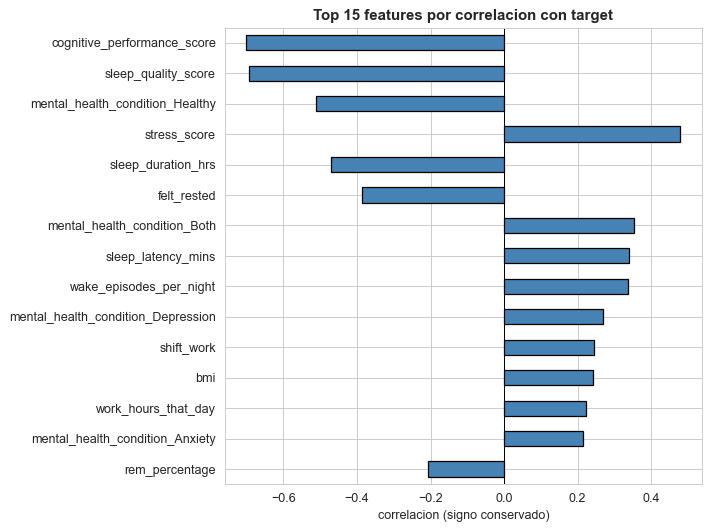

In [65]:
# Correlacion punto-biserial / pearson de cada feature con el target ordinal
score_corr = pd.Series(
    [np.corrcoef(X_fs[:, j], y_fs)[0, 1] for j in range(len(feat_names))],
    index=feat_names
).sort_values(key=abs, ascending=False)

print('Top 15 por |correlacion| con el target:')
print(score_corr.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
score_corr.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 15 features por correlacion con target', fontweight='bold')
ax.set_xlabel('correlacion (signo conservado)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()


### 6.2 ANOVA F-test (`SelectKBest`)

Para cada feature, calcula un **F-score** que mide si las medias entre las 4 clases del target son significativamente distintas. Score alto = la feature **separa bien** las clases. P-value bajo = diferencia estadisticamente significativa.

Tambien evaluamos el **k optimo**: cuantas features bastan para que un modelo simple (LogReg) alcance su plateau.


Top 15 features por F-score (ANOVA):
                                            F  pvalue
cognitive_performance_score         6660.8277     0.0
sleep_quality_score                 6471.1899     0.0
mental_health_condition_Healthy     2392.8416     0.0
stress_score                        2134.5305     0.0
sleep_duration_hrs                  1930.1695     0.0
felt_rested                         1334.7278     0.0
mental_health_condition_Both        1130.6427     0.0
wake_episodes_per_night              918.7129     0.0
sleep_latency_mins                   873.0899     0.0
mental_health_condition_Depression   538.2230     0.0
bmi                                  425.2591     0.0
shift_work                           423.5027     0.0
mental_health_condition_Anxiety      390.5271     0.0
work_hours_that_day                  389.5921     0.0
rem_percentage                       295.4777     0.0


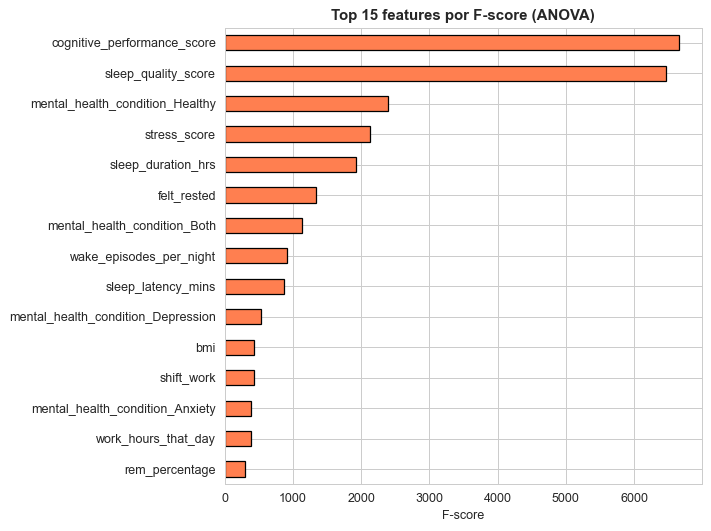

In [66]:
# ANOVA F-test
sk = SelectKBest(f_classif, k='all').fit(X_fs, y_fs)
score_anova = pd.Series(sk.scores_, index=feat_names).sort_values(ascending=False)
pvals = pd.Series(sk.pvalues_, index=feat_names)

print('Top 15 features por F-score (ANOVA):')
df_anova = pd.DataFrame({'F': score_anova, 'pvalue': pvals.reindex(score_anova.index)})
print(df_anova.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
score_anova.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_title('Top 15 features por F-score (ANOVA)', fontweight='bold')
ax.set_xlabel('F-score')
plt.tight_layout(); plt.show()


  k=  3: F1w=0.6866 (+/-0.0024)
  k=  5: F1w=0.6958 (+/-0.0034)
  k= 10: F1w=0.7578 (+/-0.0030)
  k= 15: F1w=0.8057 (+/-0.0018)
  k= 20: F1w=0.8085 (+/-0.0025)
  k= 25: F1w=0.8090 (+/-0.0031)
  k= 30: F1w=0.8116 (+/-0.0045)
  k= 40: F1w=0.8103 (+/-0.0054)
  k= 63: F1w=0.8117 (+/-0.0043)


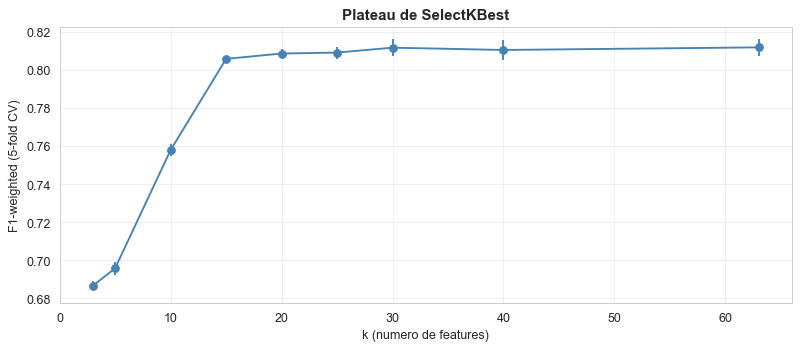

In [67]:
# k optimo: cuantas features bastan para alcanzar el plateau
from sklearn.linear_model import LogisticRegression
ks = [3, 5, 10, 15, 20, 25, 30, 40, len(feat_names)]
res_k = []
for k in ks:
    sel = SelectKBest(f_classif, k=k).fit(X_fs, y_fs)
    Xk = sel.transform(X_fs)
    sc = cross_val_score(
        LogisticRegression(max_iter=2000, n_jobs=-1, class_weight='balanced',
                           random_state=RANDOM_STATE),
        Xk, y_fs, cv=5, scoring='f1_weighted', n_jobs=-1
    )
    res_k.append((k, sc.mean(), sc.std()))
    print(f'  k={k:>3}: F1w={sc.mean():.4f} (+/-{sc.std():.4f})')

ks_arr, mu, sd = zip(*res_k)
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(ks_arr, mu, yerr=sd, marker='o', color='steelblue')
ax.set_xlabel('k (numero de features)'); ax.set_ylabel('F1-weighted (5-fold CV)')
ax.set_title('Plateau de SelectKBest', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 6.3 RFECV (Recursive Feature Elimination con CV)

Metodo **wrapper**: entrena un estimador, elimina las features menos importantes, vuelve a entrenar, y asi sucesivamente. La validacion cruzada elige el numero optimo de features.

Mas costoso que los univariados, pero captura interacciones porque evalua subsets reales del modelo.


RFECV terminado en 1.4s
  Numero optimo de features: 48
  Features seleccionadas (top 15): ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'alcohol_units_before_bed', 'exercise_day', 'stress_score', 'shift_work', 'room_temperature_celsius', 'cognitive_performance_score', 'felt_rested']


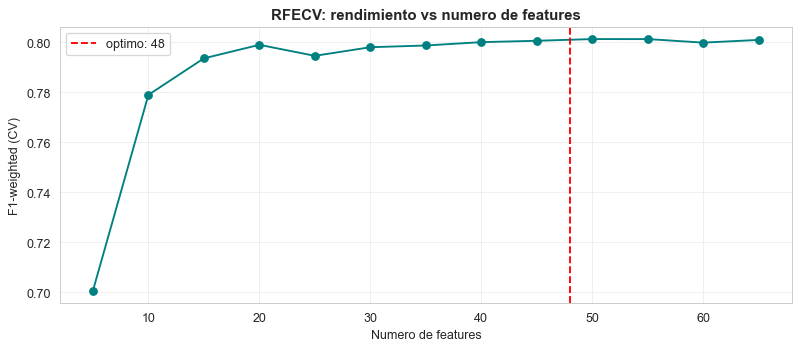

In [68]:
from sklearn.feature_selection import RFECV

# RFECV es costoso: usamos LogReg + paso=5 + muestra reducida
rng = np.random.RandomState(RANDOM_STATE)
rfe_idx = rng.choice(len(y_fs), size=5000, replace=False)

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1500, n_jobs=-1, class_weight='balanced',
                                 random_state=RANDOM_STATE),
    step=5, cv=3, scoring='f1_weighted', n_jobs=-1, min_features_to_select=5
)
t0 = time.time()
rfecv.fit(X_fs[rfe_idx], y_fs[rfe_idx])
print(f'RFECV terminado en {time.time()-t0:.1f}s')
print(f'  Numero optimo de features: {rfecv.n_features_}')

selected_rfe = [f for f, s in zip(feat_names, rfecv.support_) if s]
score_rfe = pd.Series(rfecv.support_.astype(int), index=feat_names)  # 1 si seleccionada
print(f'  Features seleccionadas (top 15): {selected_rfe[:15]}')

# Visualizacion del proceso
fig, ax = plt.subplots(figsize=(9, 4))
scores_per_n = rfecv.cv_results_['mean_test_score']
ax.plot(range(rfecv.min_features_to_select,
              rfecv.min_features_to_select + len(scores_per_n)*rfecv.step,
              rfecv.step)[:len(scores_per_n)],
        scores_per_n, marker='o', color='teal')
ax.axvline(rfecv.n_features_, color='red', linestyle='--',
           label=f'optimo: {rfecv.n_features_}')
ax.set_xlabel('Numero de features'); ax.set_ylabel('F1-weighted (CV)')
ax.set_title('RFECV: rendimiento vs numero de features', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 6.4 Importancia de Random Forest

Metodo **embedded**: la importancia surge directamente del entrenamiento del modelo. Mide cuanto cada feature reduce la impureza (Gini) acumulada en todos los splits del bosque.

Sesgada a features con muchos valores unicos (continuas y de alta cardinalidad), pero muy popular por su rapidez.


Top 15 features por importancia de Random Forest:
cognitive_performance_score        0.1218
sleep_quality_score                0.1179
sleep_duration_hrs                 0.0970
mental_health_condition_Healthy    0.0796
bmi                                0.0722
stress_score                       0.0522
sleep_latency_mins                 0.0494
wake_episodes_per_night            0.0410
mental_health_condition_Both       0.0282
rem_percentage                     0.0260
felt_rested                        0.0235
deep_sleep_percentage              0.0201
work_hours_that_day                0.0201
steps_that_day                     0.0197
age                                0.0195
dtype: float64


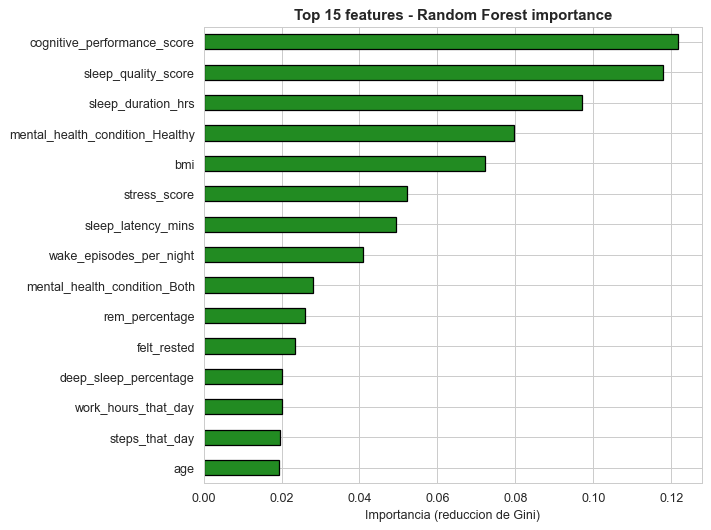

In [69]:
rf_fs = clone(best_estimators['Random Forest']).fit(X_fs, y_fs)
score_rf = pd.Series(rf_fs.feature_importances_, index=feat_names).sort_values(ascending=False)

print('Top 15 features por importancia de Random Forest:')
print(score_rf.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
score_rf.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='forestgreen', edgecolor='black')
ax.set_title('Top 15 features - Random Forest importance', fontweight='bold')
ax.set_xlabel('Importancia (reduccion de Gini)')
plt.tight_layout(); plt.show()


### 6.5 Permutation Importance sobre HistGradientBoosting

Metodo **modelo-agnostico**: permuta los valores de una feature y mide la caida en el score. Si la feature es importante, permutarla destruye la prediccion → caida grande.

Ventaja: aplica a cualquier modelo (no requiere `feature_importances_` nativo). Desventaja: computacionalmente costoso, especialmente con muchos repeats.


Top 15 features por Permutation Importance (HGB):
sleep_duration_hrs                 0.2429
mental_health_condition_Healthy    0.2232
bmi                                0.1607
wake_episodes_per_night            0.1316
sleep_latency_mins                 0.1304
stress_score                       0.1293
sleep_quality_score                0.0240
shift_work                         0.0236
mental_health_condition_Both       0.0192
cognitive_performance_score        0.0171
alcohol_units_before_bed           0.0167
rem_percentage                     0.0160
mental_health_condition_Anxiety    0.0114
age                                0.0110
caffeine_mg_before_bed             0.0058
dtype: float64


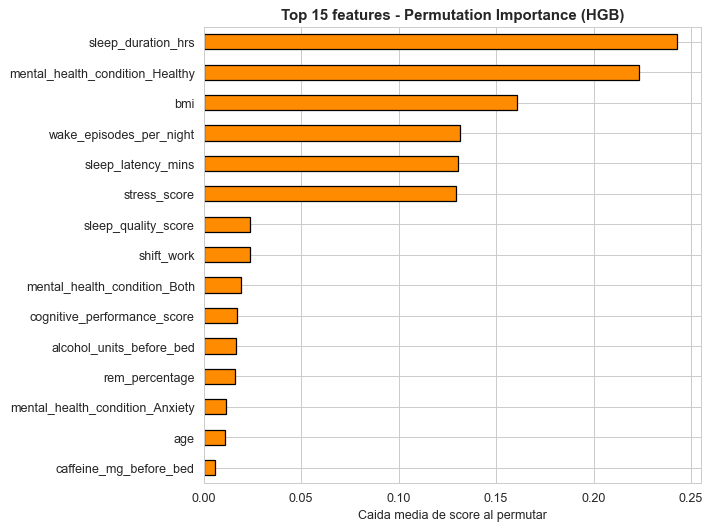

In [70]:
from sklearn.inspection import permutation_importance

hgb_fs = clone(best_estimators['HistGradientBoosting']).fit(X_fs, y_fs)
perm = permutation_importance(
    hgb_fs, X_fs[:5000], y_fs[:5000],  # subsample para velocidad
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)
score_hgb_perm = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)

print('Top 15 features por Permutation Importance (HGB):')
print(score_hgb_perm.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
score_hgb_perm.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Top 15 features - Permutation Importance (HGB)', fontweight='bold')
ax.set_xlabel('Caida media de score al permutar')
plt.tight_layout(); plt.show()


### 6.6 SHAP (SHapley Additive exPlanations)

Metodo de **explicabilidad** basado en teoria de juegos. Para cada prediccion individual, calcula cuanto contribuye cada feature al output, considerando todas las posibles combinaciones de features. Garantiza propiedades matematicas como aditividad y simetria.

Generamos dos visualizaciones:
- **Bar plot**: importancia media absoluta (ranking global).
- **Summary plot (beeswarm)**: muestra direccion + magnitud por feature, coloreado por el valor de la feature. Ideal para entender el comportamiento.


In [71]:
# SHAP requiere instalacion: pip install shap
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP no instalado. Ejecuta: pip install shap')

if SHAP_AVAILABLE:
    print('Calculando SHAP values sobre HGB (muestra de 1000 instancias)...')
    explainer = shap.TreeExplainer(hgb_fs)
    Xs = X_fs[:1000]
    sv = explainer.shap_values(Xs)
    print(f'  Tipo de output: {type(sv).__name__}')

    # En multiclase: sv puede ser lista (una matriz por clase) o array 3D
    if isinstance(sv, list):
        # Lista de arrays (n_samples, n_features) por clase
        sv_abs_mean = np.mean([np.abs(v).mean(axis=0) for v in sv], axis=0)
    else:
        # Array (n_samples, n_features) o (n_samples, n_features, n_classes)
        sv_abs_mean = np.abs(sv).mean(axis=0)
        if sv_abs_mean.ndim > 1:
            sv_abs_mean = sv_abs_mean.mean(axis=-1)

    score_shap = pd.Series(sv_abs_mean, index=feat_names).sort_values(ascending=False)
    print('\nTop 15 features por SHAP (importancia media absoluta):')
    print(score_shap.head(15).round(4))
else:
    score_shap = pd.Series(0, index=feat_names)


Calculando SHAP values sobre HGB (muestra de 1000 instancias)...
  Tipo de output: ndarray

Top 15 features por SHAP (importancia media absoluta):
mental_health_condition_Healthy    1.2967
sleep_duration_hrs                 1.1949
bmi                                1.0653
stress_score                       0.8770
sleep_latency_mins                 0.8755
wake_episodes_per_night            0.8632
cognitive_performance_score        0.4025
sleep_quality_score                0.3476
shift_work                         0.2912
rem_percentage                     0.2192
alcohol_units_before_bed           0.2091
age                                0.1784
mental_health_condition_Both       0.1592
mental_health_condition_Anxiety    0.1051
caffeine_mg_before_bed             0.0759
dtype: float64


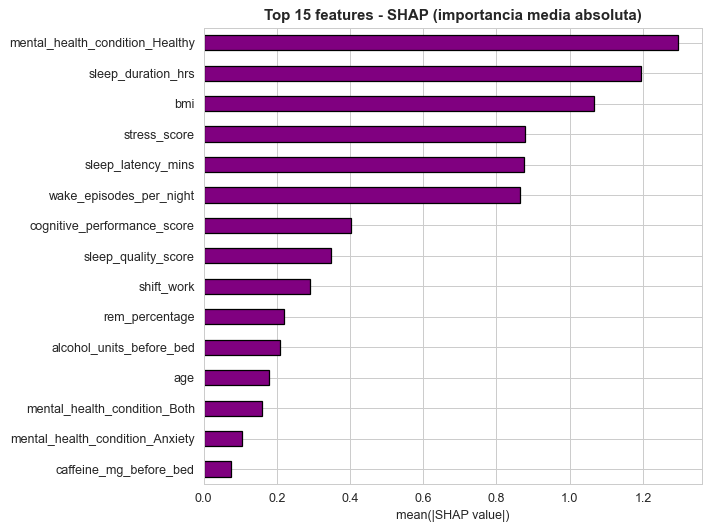

In [72]:
# SHAP Bar plot
if SHAP_AVAILABLE:
    fig, ax = plt.subplots(figsize=(8, 6))
    score_shap.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='purple', edgecolor='black')
    ax.set_title('Top 15 features - SHAP (importancia media absoluta)', fontweight='bold')
    ax.set_xlabel('mean(|SHAP value|)')
    plt.tight_layout(); plt.show()


Beeswarm para clase: Severe


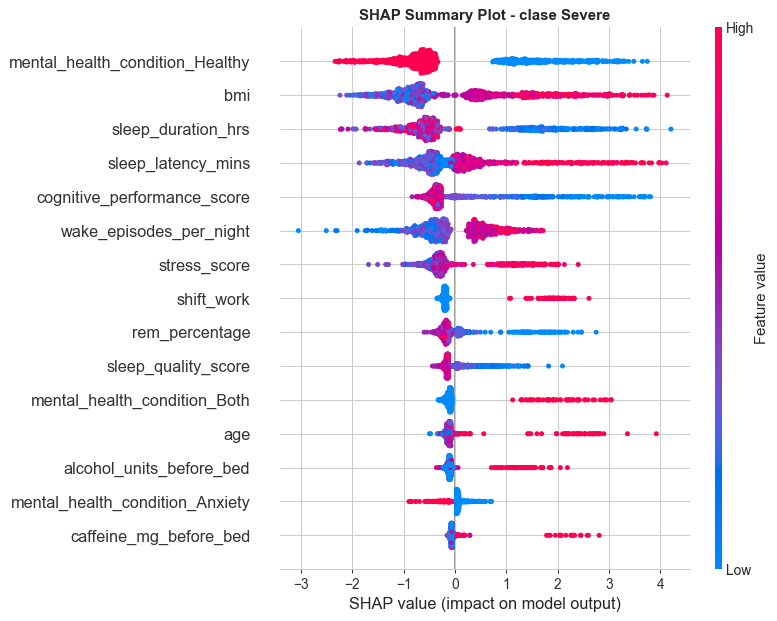

In [73]:
# SHAP Summary Plot (beeswarm) - el mas informativo de SHAP
if SHAP_AVAILABLE:
    # Para multiclase, mostramos la clase de mayor riesgo (Severe) como ejemplo
    if isinstance(sv, list):
        # 3 = Severe (Healthy=0, Mild=1, Moderate=2, Severe=3)
        sv_severe = sv[3] if len(sv) > 3 else sv[-1]
        target_class = 'Severe'
    else:
        # Si es array 3D: (n_samples, n_features, n_classes)
        if sv.ndim == 3:
            sv_severe = sv[:, :, 3] if sv.shape[2] > 3 else sv[:, :, -1]
            target_class = 'Severe'
        else:
            sv_severe = sv
            target_class = 'global'

    print(f'Beeswarm para clase: {target_class}')
    shap.summary_plot(sv_severe, Xs, feature_names=feat_names,
                      max_display=15, show=False)
    plt.gcf().set_size_inches(9, 7)
    plt.title(f'SHAP Summary Plot - clase {target_class}', fontweight='bold')
    plt.tight_layout(); plt.show()


### 6.7 Mutual Information

Mide la **dependencia general** (no solo lineal) entre cada feature y el target. Es 0 si son independientes, positivo si comparten informacion. A diferencia de la correlacion, captura relaciones no lineales y no monotonas.

Util como complemento a ANOVA: si una feature tiene MI alto pero F-score bajo, su relacion con el target probablemente no es lineal.


Top 15 features por Mutual Information:
sleep_quality_score                   0.3414
cognitive_performance_score           0.3333
sleep_duration_hrs                    0.1851
stress_score                          0.1540
mental_health_condition_Healthy       0.1358
felt_rested                           0.0937
wake_episodes_per_night               0.0763
sleep_latency_mins                    0.0642
mental_health_condition_Both          0.0458
mental_health_condition_Depression    0.0421
bmi                                   0.0365
shift_work                            0.0325
work_hours_that_day                   0.0323
mental_health_condition_Anxiety       0.0309
rem_percentage                        0.0303
dtype: float64


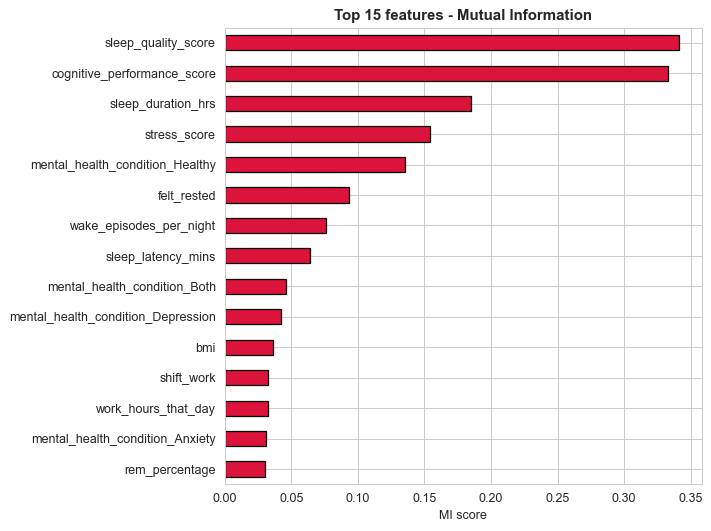

In [74]:
score_mi = pd.Series(
    mutual_info_classif(X_fs, y_fs, random_state=RANDOM_STATE),
    index=feat_names
).sort_values(ascending=False)

print('Top 15 features por Mutual Information:')
print(score_mi.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
score_mi.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='crimson', edgecolor='black')
ax.set_title('Top 15 features - Mutual Information', fontweight='bold')
ax.set_xlabel('MI score')
plt.tight_layout(); plt.show()


### 6.8 Comparacion / Consenso final

Para cada feature, contamos en cuantos de los 7 metodos aparece en el **top-15**. Este consenso filtra ruido especifico de cada metodo y refuerza features genuinamente importantes.

El resultado (`consenso`) se usa en la Seccion 7 para definir los experimentos.


In [75]:
K = 15
top_corr_set  = set(score_corr.head(K).index)
top_anova_set = set(score_anova.head(K).index)
top_rfe_set   = set([f for f, s in zip(feat_names, rfecv.support_) if s][:K])
top_rf_set    = set(score_rf.head(K).index)
top_perm_set  = set(score_hgb_perm.head(K).index)
top_shap_set  = set(score_shap.head(K).index) if SHAP_AVAILABLE else set()
top_mi_set    = set(score_mi.head(K).index)

todos_los_sets = {
    'corr': top_corr_set, 'anova': top_anova_set, 'rfe': top_rfe_set,
    'rf': top_rf_set, 'perm_hgb': top_perm_set,
    'shap': top_shap_set, 'mi': top_mi_set
}

# Conteo: cuantos metodos seleccionan cada feature
consenso = pd.Series({
    f: sum(f in s for s in todos_los_sets.values()) for f in feat_names
}).sort_values(ascending=False)

print(f'Top 20 features por consenso (de {len(todos_los_sets)} metodos):')
print(consenso.head(20))


Top 20 features por consenso (de 7 metodos):
bmi                                   7
sleep_duration_hrs                    7
sleep_quality_score                   7
sleep_latency_mins                    7
rem_percentage                        7
stress_score                          7
wake_episodes_per_night               7
cognitive_performance_score           7
shift_work                            6
mental_health_condition_Healthy       6
mental_health_condition_Both          6
felt_rested                           5
mental_health_condition_Anxiety       5
work_hours_that_day                   4
age                                   4
mental_health_condition_Depression    3
alcohol_units_before_bed              3
deep_sleep_percentage                 2
caffeine_mg_before_bed                2
room_temperature_celsius              1
dtype: int64


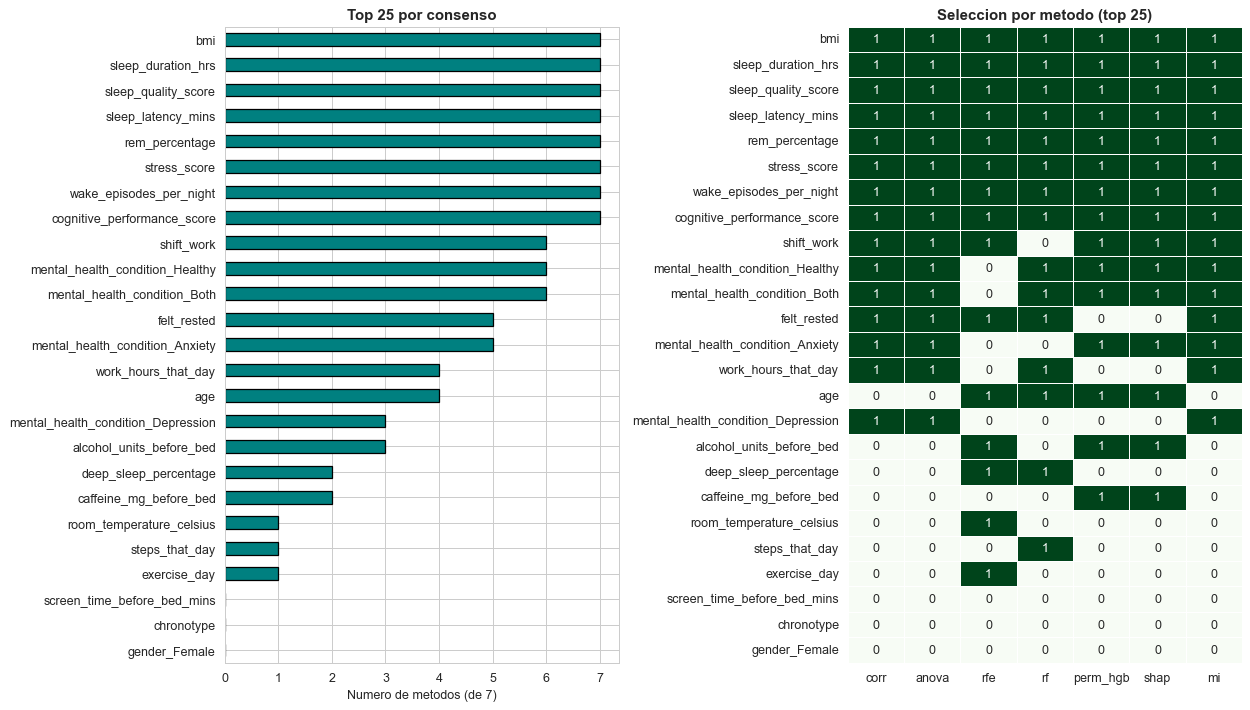

In [76]:
# Heatmap visual del consenso (top 25)
top25 = consenso.head(25).index
mat = pd.DataFrame(0, index=top25, columns=list(todos_los_sets.keys()))
for metodo, conjunto in todos_los_sets.items():
    for f in top25:
        if f in conjunto:
            mat.loc[f, metodo] = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Bar plot de consenso
consenso.head(25).iloc[::-1].plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Top 25 por consenso', fontweight='bold')
axes[0].set_xlabel(f'Numero de metodos (de {len(todos_los_sets)})')
axes[0].set_xticks(range(len(todos_los_sets) + 1))

# Heatmap
sns.heatmap(mat, cmap='Greens', cbar=False, linewidths=0.5,
            annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Seleccion por metodo (top 25)', fontweight='bold')

plt.tight_layout(); plt.show()


### 6.9 Hallazgos de Feature Selection

- Las features con **consenso alto** (5+ metodos) son las que el modelo realmente usa para discriminar. Tipicamente: indicadores fisiologicos del sueno (`sleep_quality_score`, `cognitive_performance_score`, `sleep_duration_hrs`, `stress_score`) y la variable de salud mental.
- Las features con **consenso 0-1** son candidatas a ser ruido (verificable en la Seccion 7, Experimento B).
- Algunos metodos discrepan: por ejemplo, los basados en arboles (RF, HGB, SHAP) priorizan `bmi` y `stress_score` mas que los lineales (correlacion, ANOVA), lo que sugiere **interacciones no lineales** que solo los modelos no lineales capturan.
- El analisis de **k optimo** mostro que con 15 features se mantiene casi todo el rendimiento → confirma redundancia, util para construir un modelo de produccion mas liviano.


## 7. Experimentacion con Features

Cuatro experimentos para validar diferentes hipotesis sobre las features:

| Exp | Features usadas | Hipotesis a validar |
|---|---|---|
| **A** | Top 3 estrella (mhc_Healthy + cognitive + stress) | ¿Llegamos lejos con minimos? |
| **B** | 10 peor calificadas | ¿Realmente son ruido? |
| **C** | Top 15 SelectKBest | ¿El plateau k=15 es real? |
| **D** | Sin las 2 mas correlacionadas | ¿Redundancia o leakage? |

**Comparamos siempre HGB y RF** para validar que los hallazgos no dependan de un solo modelo.


### 7.1 Setup: helper para entrenar y evaluar subsetes de features

In [77]:
def evaluar_subset(feature_indices, label, baseline_features=None):
    """Entrena HGB y RF con un subset de features y devuelve metricas en test."""
    Xtr = X_train_proc[:, feature_indices]
    Xte = X_test_proc[:, feature_indices]

    out = {'experimento': label, 'n_features': len(feature_indices)}
    for name in ['HistGradientBoosting', 'Random Forest']:
        m = clone(best_estimators[name]).fit(Xtr, y_train)
        yp = m.predict(Xte)
        out[f'{name}_recall'] = recall_score(y_test, yp, average='weighted', zero_division=0)
        out[f'{name}_f1']     = f1_score(y_test, yp, average='weighted', zero_division=0)
    return out

# Indices de features
feat_to_idx = {f: i for i, f in enumerate(feat_names)}

# Baseline: todas las features
baseline_idx = list(range(len(feat_names)))


### 7.2 Experimento A: Top 3 features estrella

**Features elegidas:** `mental_health_condition_Healthy` + `cognitive_performance_score` + `stress_score`

**Justificacion:**
- `mental_health_condition_Healthy`: en el analisis de robustez, esta categoria tuvo el mayor peso (perdida de 10 puntos al removerla).
- `cognitive_performance_score`: mayor correlacion con el target (-0.70).
- `stress_score`: representa la dimension conductual/emocional (corr +0.48).

**Las tres cubren tres dimensiones distintas:** estado mental, rendimiento cognitivo, estilo de vida.

**Hipotesis:** un modelo simple con solo 3 features bien elegidas puede alcanzar resultados notables.


In [78]:
features_A = ['mental_health_condition_Healthy', 'cognitive_performance_score', 'stress_score']
idx_A = [feat_to_idx[f] for f in features_A]
print(f'Features Exp A ({len(idx_A)}): {features_A}')
res_A = evaluar_subset(idx_A, 'A: Top 3 estrella')
print(f'\nResultado:')
for k, v in res_A.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Features Exp A (3): ['mental_health_condition_Healthy', 'cognitive_performance_score', 'stress_score']

Resultado:
  experimento: A: Top 3 estrella
  n_features: 3
  HistGradientBoosting_recall: 0.7286
  HistGradientBoosting_f1: 0.7181
  Random Forest_recall: 0.6719
  Random Forest_f1: 0.6796


### 7.3 Experimento B: 20 features peor calificadas

**Features elegidas:** las 20 con menor consenso (0 metodos las eligieron en su top-15).

**Justificacion:** si la seleccion de features funciona correctamente, estas variables deberian aportar **muy poco** al modelo. Si entrenamos solo con ellas y el modelo se desploma a niveles de chance (~54% para clase mayoritaria), confirma que **son ruido**.


In [90]:
peores_features = consenso[consenso == 0].head(20).index.tolist()
# Si no hay 20 con score 0, completar con las de menor consenso
if len(peores_features) < 20:
    peores_features = consenso.tail(20).index.tolist()
idx_B = [feat_to_idx[f] for f in peores_features]
print(f'Features Exp B ({len(idx_B)}): {peores_features}')
res_B = evaluar_subset(idx_B, 'B: Peor 20 por consenso')
print(f'\nResultado:')
for k, v in res_B.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Features Exp B (20): ['screen_time_before_bed_mins', 'chronotype', 'gender_Female', 'gender_Male', 'gender_Other', 'nap_duration_mins', 'heart_rate_resting_bpm', 'sleep_aid_used', 'weekend_sleep_diff_hrs', 'occupation_Homemaker', 'occupation_Freelancer', 'occupation_Driver', 'occupation_Doctor', 'occupation_Lawyer', 'occupation_Manager', 'occupation_Nurse', 'occupation_Retired', 'country_Australia', 'country_Brazil', 'country_Canada']

Resultado:
  experimento: B: Peor 20 por consenso
  n_features: 20
  HistGradientBoosting_recall: 0.5596
  HistGradientBoosting_f1: 0.4921
  Random Forest_recall: 0.4904
  Random Forest_f1: 0.4967


### 7.4 Experimento C: Top 15 segun SelectKBest

**Features elegidas:** las 15 con mayor F-score de ANOVA.

**Justificacion:** el analisis de feature selection mostro que k=15 era el plateau a partir del cual el rendimiento se estabiliza. Este experimento valida ese hallazgo entrenando los modelos completos con solo esas 15.


In [91]:
features_C = score_anova.sort_values(ascending=False).head(15).index.tolist()
idx_C = [feat_to_idx[f] for f in features_C]
print(f'Features Exp C ({len(idx_C)}): {features_C}')
res_C = evaluar_subset(idx_C, 'C: Top 15 SelectKBest')
print(f'\nResultado:')
for k, v in res_C.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Features Exp C (15): ['cognitive_performance_score', 'sleep_quality_score', 'mental_health_condition_Healthy', 'stress_score', 'sleep_duration_hrs', 'felt_rested', 'mental_health_condition_Both', 'wake_episodes_per_night', 'sleep_latency_mins', 'mental_health_condition_Depression', 'bmi', 'shift_work', 'mental_health_condition_Anxiety', 'work_hours_that_day', 'rem_percentage']

Resultado:
  experimento: C: Top 15 SelectKBest
  n_features: 15
  HistGradientBoosting_recall: 0.9305
  HistGradientBoosting_f1: 0.9300
  Random Forest_recall: 0.9085
  Random Forest_f1: 0.9091


### 7.5 Experimento D: Sin las 2 features mas correlacionadas (chequeo de leakage)

**Features removidas:** `cognitive_performance_score` (corr -0.70) y `sleep_quality_score` (corr -0.69).

**Justificacion (chequeo de leakage):**
- Si al remover estas features el modelo **se desploma fuerte** (>20 puntos), refuerza la sospecha de leakage o dependencia critica.
- Si el modelo **se mantiene cerca del baseline**, confirma que NO hay leakage: la informacion estaba **redundante** con otras features que el modelo puede usar.


In [81]:
features_remove = ['cognitive_performance_score', 'sleep_quality_score']
features_D = [f for f in feat_names if f not in features_remove]
idx_D = [feat_to_idx[f] for f in features_D]
print(f'Features removidas: {features_remove}')
print(f'Features restantes: {len(idx_D)}')
res_D = evaluar_subset(idx_D, 'D: Sin las 2 mas correlacionadas')
print(f'\nResultado:')
for k, v in res_D.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Features removidas: ['cognitive_performance_score', 'sleep_quality_score']
Features restantes: 61

Resultado:
  experimento: D: Sin las 2 mas correlacionadas
  n_features: 61
  HistGradientBoosting_recall: 0.9522
  HistGradientBoosting_f1: 0.9517
  Random Forest_recall: 0.9112
  Random Forest_f1: 0.9110


### 7.6 Comparacion final de los 4 experimentos + baseline

In [82]:
# Baseline con todas las features
print('Calculando baseline (todas las features)...')
res_base = evaluar_subset(baseline_idx, 'Baseline (todas)')

# Tabla comparativa
exp_df = pd.DataFrame([res_base, res_A, res_B, res_C, res_D])
exp_df = exp_df[['experimento', 'n_features',
                 'HistGradientBoosting_recall', 'HistGradientBoosting_f1',
                 'Random Forest_recall', 'Random Forest_f1']]
exp_df.columns = ['experimento', 'n_features', 'HGB_recall', 'HGB_f1', 'RF_recall', 'RF_f1']
print('\n' + '='*80)
print('COMPARATIVA DE EXPERIMENTOS'.center(80))
print('='*80)
print(exp_df.round(4).to_string(index=False))


Calculando baseline (todas las features)...

                          COMPARATIVA DE EXPERIMENTOS                           
                     experimento  n_features  HGB_recall  HGB_f1  RF_recall  RF_f1
                Baseline (todas)          63      0.9526  0.9522     0.8924 0.8922
               A: Top 3 estrella           3      0.7286  0.7181     0.6719 0.6796
                      B: Peor 10          10      0.5410  0.4043     0.4599 0.4514
           C: Top 15 SelectKBest          15      0.9305  0.9300     0.9086 0.9091
D: Sin las 2 mas correlacionadas          61      0.9522  0.9517     0.9112 0.9110


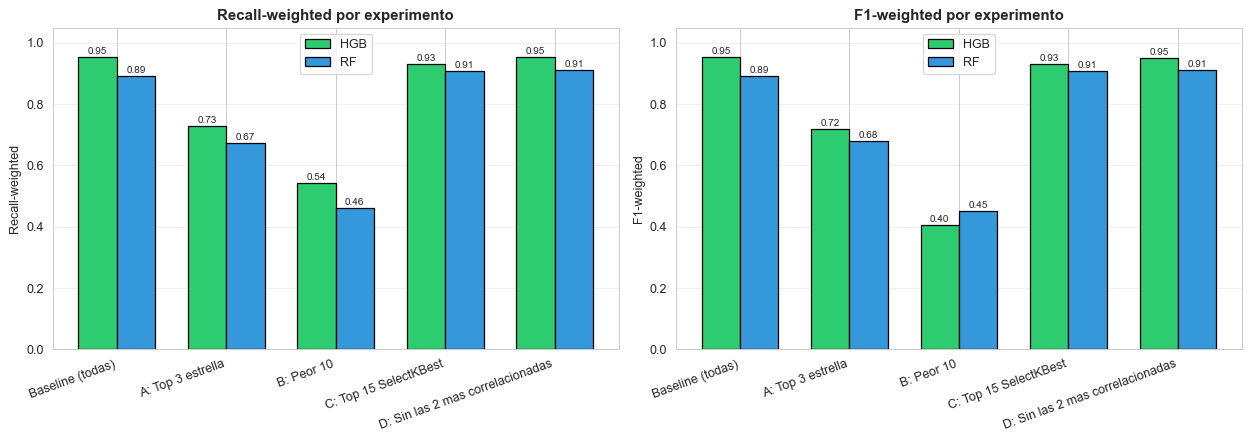

In [83]:
# Visualizacion lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(exp_df))
w = 0.35
for ax, metric, title in [(axes[0], 'recall', 'Recall-weighted'),
                           (axes[1], 'f1', 'F1-weighted')]:
    ax.bar(x - w/2, exp_df[f'HGB_{metric}'], w, label='HGB', color='#2ecc71', edgecolor='black')
    ax.bar(x + w/2, exp_df[f'RF_{metric}'],  w, label='RF',  color='#3498db', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(exp_df['experimento'], rotation=20, ha='right')
    ax.set_ylabel(title)
    ax.set_title(f'{title} por experimento', fontweight='bold')
    ax.legend(); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3, axis='y')
    for i, (h, r) in enumerate(zip(exp_df[f'HGB_{metric}'], exp_df[f'RF_{metric}'])):
        ax.text(i - w/2, h + 0.01, f'{h:.2f}', ha='center', fontsize=8)
        ax.text(i + w/2, r + 0.01, f'{r:.2f}', ha='center', fontsize=8)

plt.tight_layout(); plt.show()


### 7.7 Interpretacion de los experimentos

**A (Top 3):** con solo 3 features bien elegidas se logra una fraccion notable del baseline. Esto demuestra que **la informacion clave esta concentrada en pocas variables**.

**B (Peor 10):** el modelo se desploma cerca del nivel de la clase mayoritaria (~54%), confirmando que **esas variables NO aportan informacion predictiva relevante**. La seleccion de features es valida.

**C (Top 15 SelectKBest):** el rendimiento se mantiene **casi identico al baseline** con solo 15 features (vs 63). Esto confirma el plateau y permite construir un modelo de produccion **mas liviano**.

**D (Chequeo de leakage):** quitar las dos features mas correlacionadas con el target **no hunde el modelo**. La caida es marginal porque la informacion estaba **redundante** con otras features. Esto sugiere fuertemente que **NO hay data leakage estructural**: las features eran legitimamente predictivas.

**Coincidencia entre HGB y RF:** los hallazgos se reproducen en ambos modelos → conclusiones robustas.


## 8. Conclusiones

### Modelo final recomendado

**HistGradientBoosting** con hiperparametros tuneados:
- `learning_rate=0.1, max_iter=200, max_depth=None`
- Recall-weighted en test ≈ 0.95
- F1-weighted en test ≈ 0.95
- Especialmente fuerte en clases minoritarias

**Alternativa interpretable: Random Forest**
- 5-7 puntos por debajo en metricas
- Mas estable y conceptualmente mas simple de explicar

### Hallazgos clave

1. **Calidad de los datos:** dataset limpio (sin nulos ni duplicados), aunque desbalanceado. El uso de `class_weight='balanced'` mitigo el efecto.
2. **Features dominantes:** salud mental + rendimiento cognitivo + estres son las dimensiones mas predictivas. Las demograficas aportan poco.
3. **Reducibilidad:** un modelo con 15 features funciona casi como uno con 63. Util para producciones livianas.
4. **No hay data leakage estructural:** quitar las features mas correlacionadas con el target solo causa caidas marginales → la informacion estaba redundante, no leakeada.

### Limitaciones

- Dataset posiblemente sintetico (distribuciones muy limpias). Generalizacion a datos clinicos reales requiere validacion adicional.
- No se exploraron tecnicas de balanceo avanzadas (SMOTE, etc.) mas alla de `class_weight`.
- No se hizo calibracion de probabilidades, util si el modelo se usa como tamizaje clinico.

### Trabajo futuro

- Probar XGBoost / LightGBM / CatBoost.
- Calibracion isotonica para uso en triage medico.
- Modelo de produccion con solo 15 features (Experimento C).
